# Pipeline ML — Dimensionnement et répartition des opérateurs par pôle

**Objectif** : Prédire le volume d'activité du lendemain pour chaque pôle opérationnel (BULK, PICKING, PROMO, GLOBAL), puis convertir ces volumes en nombre d'opérateurs nécessaires.

**Structure du notebook :**
1. Chargement et exploration des données
2. Agrégation quotidienne par pôle
3. Feature engineering
4. Walk-forward validation
5. Entraînement des modèles XGBoost (un par pôle)
6. Évaluation des performances
7. Conversion volume → opérateurs
8. Simulation : prédiction J+1 en conditions réelles

## 0. Imports et configuration

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import optuna

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor  
from joblib import Parallel, delayed optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.1f}'.format)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

POLES = ['BULK', 'PICKING', 'PROMO', 'GLOBAL']
RANDOM_SEED = 42

print('Imports OK')

Imports OK


## 1. Chargement des données

Les fichiers attendus sont au format :
- `DATE` : date de l'opération
- `WORKFLOW` : code de type `PREPARATION_{S|W}_{BULK|PICKING|PROMO|GLOBAL}_{Pays}`
- `QUANTITY` : volume traité

> **Adaptez la variable `DATA_FOLDER`** pour pointer vers votre dossier contenant les fichiers 2023.xlsx, 2024.xlsx, etc.

In [14]:
# ─── CONFIGURATION ───────────────────────────────────────────────────────────
DATA_FOLDER = Path('../DATA/')          # Dossier contenant vos fichiers .xlsx
SHEET_NAME  = 'Grid Results'        # Onglet Excel
# ─────────────────────────────────────────────────────────────────────────────

def load_all_files(folder: Path, sheet: str) -> pd.DataFrame:
    """Charge tous les fichiers .xlsx du dossier et les concatène."""
    files = sorted(folder.glob('20*.xlsx'))
    if not files:
        raise FileNotFoundError(f"Aucun fichier trouvé dans {folder}")

    frames = []
    for f in files:
        try:
            xls = pd.ExcelFile(f)
        except Exception as exc:
            warnings.warn(f"Impossible de lire {f.name} : {exc}")
            continue

        if sheet not in xls.sheet_names:
            warnings.warn(f"Fichier ignoré : {f.name} ne contient pas l'onglet '{sheet}'")
            continue

        df = pd.read_excel(f, sheet_name=sheet, header=0)
        df.columns = df.columns.str.strip().str.upper()
        frames.append(df)
        print(f"  OK {f.name} — {len(df):,} lignes")

    if not frames:
        raise FileNotFoundError(
            f"Aucun fichier valide trouvé dans {folder} avec l'onglet '{sheet}'"
        )

    raw = pd.concat(frames, ignore_index=True)
    raw['DATE'] = pd.to_datetime(raw['DATE'])
    raw = raw.sort_values('DATE').drop_duplicates()
    return raw

print(f"Chargement depuis : {DATA_FOLDER.resolve()}")
raw = load_all_files(DATA_FOLDER, SHEET_NAME)

print(f"\nTotal : {len(raw):,} lignes | Période : {raw['DATE'].min().date()} → {raw['DATE'].max().date()}")
raw.head()

Chargement depuis : C:\Users\Rodri\Desktop\UTT\P26\crunch\DATA
  OK 2023.xlsx — 13,583 lignes
  OK 2024.xlsx — 19,413 lignes
  OK 2025.xlsx — 18,341 lignes
  OK 2026.xlsx — 2,958 lignes

Total : 54,295 lignes | Période : 2023-01-05 → 2026-02-27


,DATE,WORKFLOW,QUANTITY
0,2023-01-05,PREPARATION_S_BULK_New Zealand,2
1,2023-01-05,PREPARATION_S_GLOBAL,2
2,2023-01-06,PREPARATION_S_BULK_Japan,15
3,2023-01-06,PREPARATION_S_GLOBAL,52
4,2023-01-06,PREPARATION_S_PICKING_Japan,37


## 2. Parsing du WORKFLOW et agrégation par pôle

In [ ]:
def parse_workflow(wf: str):
    """Extrait (saison, type_op, pays) depuis un code WORKFLOW."""
    m = re.match(r'PREPARATION_([SW])_(BULK|PICKING|GLOBAL|PROMO)(?:_(.+))?', wf)
    if m:
        return m.group(1), m.group(2), m.group(3) or 'ALL'
    return None, None, None

parsed = raw['WORKFLOW'].apply(lambda x: pd.Series(parse_workflow(x),
                                                    index=['SAISON','TYPE_OP','PAYS']))
raw = pd.concat([raw, parsed], axis=1)

# Statistiques exploratoires
print("Types d'opération :")
print(raw['TYPE_OP'].value_counts().to_frame('count'))
print(f"\nNombre de pays distincts : {raw['PAYS'].nunique()}")
print(f"Saisons : {raw['SAISON'].value_counts().to_dict()}")

Types d'opération :
         count
TYPE_OP       
PICKING  18706
BULK     17203
PROMO    16874
GLOBAL    1512

Nombre de pays distincts : 66
Saisons : {'W': 33108, 'S': 21187}


In [ ]:
# ── Agrégation : une ligne = un jour, une colonne = volume par pôle ──────────
daily = (
    raw
    .groupby(['DATE', 'TYPE_OP'])['QUANTITY']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)
daily.columns.name = None

# Colonnes contextuelles utiles : nb de pays actifs ce jour
nb_pays = raw.groupby('DATE')['PAYS'].nunique().rename('NB_PAYS')
daily = daily.merge(nb_pays, on='DATE', how='left')

# Après le merge NB_PAYS et avant "Volume total", ajouter : 
# ── Réindexation sur calendrier continu ────────────────────────────── 
date_range = pd.date_range(daily['DATE'].min(), daily['DATE'].max(), freq='D') 
daily = daily.set_index('DATE').reindex(date_range).rename_axis('DATE').reset_index() 
daily[POLES] = daily[POLES].fillna(0) 
daily['NB_PAYS'] = daily['NB_PAYS'].fillna(0) 
daily['TOTAL'] = daily[POLES].sum(axis=1)

# S'assurer que tous les pôles sont présents
for p in POLES:
    if p not in daily.columns:
        daily[p] = 0

# Volume total
daily['TOTAL'] = daily[POLES].sum(axis=1)

print(f"Jours d'activité : {len(daily)}")
display(daily.describe())

Jours d'activité : 766


,DATE,BULK,GLOBAL,PICKING,PROMO,NB_PAYS,TOTAL
count,766,766.0,766.0,766.0,766.0,766.0,766.0
mean,2024-08-21 02:15:21.148825,1111.8,26153.7,16515.0,8526.8,21.7,52307.3
min,2023-01-05 00:00:00,0.0,1.0,0.0,0.0,2.0,2.0
25%,2023-11-17 18:00:00,725.2,16929.5,10465.0,5308.0,20.0,33859.0
50%,2024-08-21 12:00:00,986.0,23239.0,13999.5,8294.0,22.0,46478.0
75%,2025-05-26 18:00:00,1410.0,34737.8,21649.0,12102.8,25.0,69475.5
max,2026-02-27 00:00:00,3983.0,90139.0,72215.0,25685.0,34.0,180278.0
std,NaN,580.4,13961.0,9392.8,5500.1,4.9,27921.9


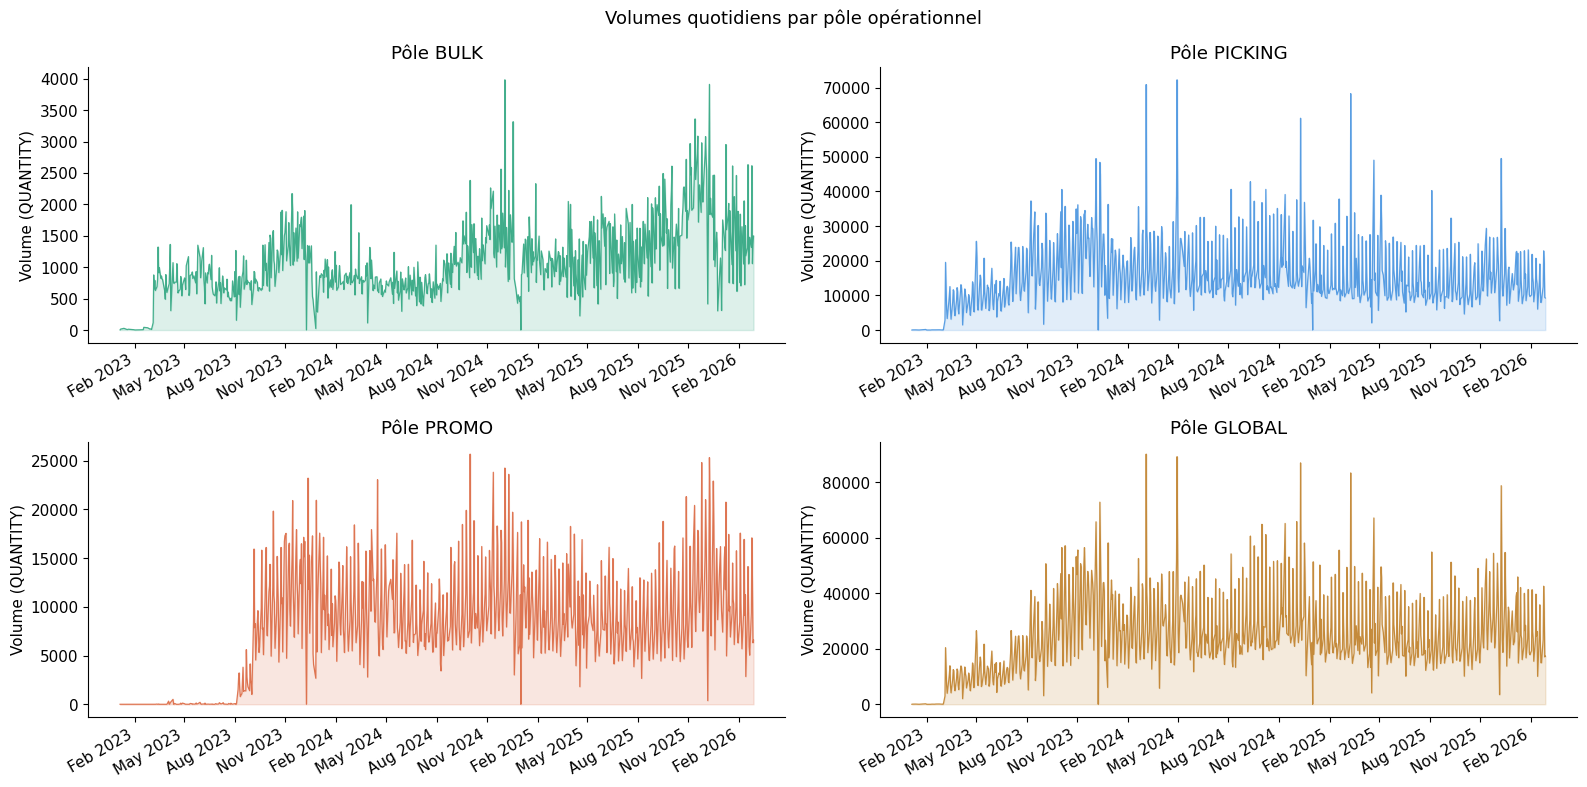

In [17]:
# ── Visualisation des volumes par pôle ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
colors = ['#1D9E75', '#378ADD', '#D85A30', '#BA7517']

for ax, pole, color in zip(axes.flat, POLES, colors):
    ax.plot(daily['DATE'], daily[pole], color=color, linewidth=0.9, alpha=0.8)
    ax.fill_between(daily['DATE'], daily[pole], alpha=0.15, color=color)
    ax.set_title(f'Pôle {pole}', fontweight='500')
    ax.set_ylabel('Volume (QUANTITY)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('Volumes quotidiens par pôle opérationnel', fontsize=13, fontweight='500')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

On construit les features **uniquement à partir d'informations connues au moment de la prédiction (J)** pour prédire J+1, afin d'éviter tout data leakage.

In [ ]:
# ── Jours fériés français (liste non-exhaustive, à compléter selon vos années) ──
FERIES_FR = pd.to_datetime([
    '2023-01-01','2023-04-10','2023-05-01','2023-05-08','2023-05-18','2023-05-29',
    '2023-07-14','2023-08-15','2023-11-01','2023-11-11','2023-12-25',
    '2024-01-01','2024-04-01','2024-05-01','2024-05-08','2024-05-09','2024-05-20',
    '2024-07-14','2024-08-15','2024-11-01','2024-11-11','2024-12-25',
    '2025-01-01','2025-04-21','2025-05-01','2025-05-08','2025-05-29','2025-06-09',
    '2025-07-14','2025-08-15','2025-11-01','2025-11-11','2025-12-25',
    '2026-01-01','2026-04-06','2026-05-01','2026-05-08','2026-05-14','2026-05-25',
    '2026-07-14','2026-08-15','2026-11-01','2026-11-11','2026-12-25',
])

def build_features(df, poles, lags=[1,7,14,28,365], windows=[7,14,28,90]): 
    out = df.copy().sort_values('DATE').reset_index(drop=True) 
    # Temporelles (inchangées) 
    out['DOW'] = out['DATE'].dt.dayofweek 
    out['WEEK'] = out['DATE'].dt.isocalendar().week.astype(int) 
    out['MONTH'] = out['DATE'].dt.month 
    out['QUARTER'] = out['DATE'].dt.quarter 
    out['DAY_OF_YEAR'] = out['DATE'].dt.dayofyear 
    out['YEAR'] = out['DATE'].dt.year 
    out['IS_FERIE'] = out['DATE'].isin(FERIES_FR).astype(int) 
    out['IS_VEILLE_FERIE'] = out['DATE'].apply( lambda d: (d + pd.Timedelta(days=1)) in FERIES_FR).astype(int) 
    out['DOW_SIN'] = np.sin(2*np.pi*out['DOW']/7) 
    out['DOW_COS'] = np.cos(2*np.pi*out['DOW']/7) 
    out['MONTH_SIN'] = np.sin(2*np.pi*out['MONTH']/12) 
    out['MONTH_COS'] = np.cos(2*np.pi*out['MONTH']/12) 
    # Pics saisonniers (inchangés) 
    out['BLACK_FRIDAY'] = ((out['MONTH']==11)&(out['DATE'].dt.day>=20)).astype(int) 
    out['NOEL_PEAK'] = ((out['MONTH']==12)&(out['DATE'].dt.day<=24)).astype(int) 
    out['SOLDES'] = (((out['MONTH']==1)) | ((out['MONTH']==6)&(out['DATE'].dt.day>=24))).astype(int) 
    # NOUVEAU — Transitions saisonnières S→W et W→S 
    # Transition W→S : mars-avril | Transition S→W : août-septembre 
    out['TRANS_W2S'] = ((out['MONTH'].isin([3,4]))).astype(int) 
    out['TRANS_S2W'] = ((out['MONTH'].isin([8,9]))).astype(int) 
    # Semaines restantes avant la transition (signal précoce) 
    out['WEEKS_TO_TRANS'] = out['DATE'].apply(lambda d: min( abs((d - pd.Timestamp(f'{d.year}-04-01')).days), abs((d - pd.Timestamp(f'{d.year}-09-01')).days) ) // 7) 
    # Lags et rolling — calculés sur calendrier continu (bug corrigé) 
    
    for pole in poles: 
        for lag in lags: 
            out[f'{pole}_LAG{lag}'] = out[pole].shift(lag) 
            for w in windows: 
                out[f'{pole}_ROLL{w}'] = out[pole].shift(1).rolling(w, min_periods=1).mean() 
                # NOUVEAU — Tendance long terme (corrige le biais de sur-prédiction) 
                out[f'{pole}_TREND90'] = out[pole].shift(1).rolling(90, min_periods=14).mean() 
                # NOUVEAU — Ratio variation semaine/semaine (signal de momentum) 
                roll7 = out[pole].shift(1).rolling(7, min_periods=1).mean() 
                roll14 = out[pole].shift(8).rolling(7, min_periods=1).mean() 
                out[f'{pole}_WOW'] = (roll7 / (roll14 + 1e-6)).clip(0, 5) 
                # NOUVEAU — NB_PAYS comme feature (proxy de complexité) 
                out['NB_PAYS_LAG1'] = out['NB_PAYS'].shift(1) 
                out['NB_PAYS_ROLL7'] = out['NB_PAYS'].shift(1).rolling(7, min_periods=1).mean() 
                for lag in [1, 7]: 
                    out[f'TOTAL_LAG{lag}'] = out['TOTAL'].shift(lag) 
                    for pole in poles: 
                        out[f'TARGET_{pole}'] = out[pole].shift(-1) 
    return out

features_df = build_features(daily, POLES)

# Colonnes de features (on exclut les cibles et la date)
FEATURE_COLS = [c for c in features_df.columns
                if c not in ['DATE'] + POLES + ['TOTAL', 'NB_PAYS']
                and not c.startswith('TARGET_')]

print(f"Features construites : {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Features construites : 47
['DOW', 'WEEK', 'MONTH', 'QUARTER', 'DAY_OF_YEAR', 'YEAR', 'IS_FERIE', 'IS_VEILLE_FERIE', 'DOW_SIN', 'DOW_COS', 'BLACK_FRIDAY', 'NOEL_PEAK', 'SOLDES', 'BULK_LAG1', 'BULK_LAG7', 'BULK_LAG14', 'BULK_LAG28', 'BULK_LAG365', 'BULK_ROLL7', 'BULK_ROLL14', 'BULK_ROLL28', 'PICKING_LAG1', 'PICKING_LAG7', 'PICKING_LAG14', 'PICKING_LAG28', 'PICKING_LAG365', 'PICKING_ROLL7', 'PICKING_ROLL14', 'PICKING_ROLL28', 'PROMO_LAG1', 'PROMO_LAG7', 'PROMO_LAG14', 'PROMO_LAG28', 'PROMO_LAG365', 'PROMO_ROLL7', 'PROMO_ROLL14', 'PROMO_ROLL28', 'GLOBAL_LAG1', 'GLOBAL_LAG7', 'GLOBAL_LAG14', 'GLOBAL_LAG28', 'GLOBAL_LAG365', 'GLOBAL_ROLL7', 'GLOBAL_ROLL14', 'GLOBAL_ROLL28', 'TOTAL_LAG1', 'TOTAL_LAG7']


## 4. Walk-Forward Validation

On simule les conditions réelles : le modèle ne voit jamais le futur lors de l'évaluation.

```
Train ─────────────────────┤ Test │
                           ↓
Train ──────────────────────────┤ Test │
                                ↓
        ... expansion progressive ...
```

In [19]:
def walk_forward_split(df: pd.DataFrame,
                       train_start: str,
                       test_start: str,
                       step_days: int = 7):
    """
    Génère des splits (train_idx, test_idx) en expanding window.
    - train_start : début de la période d'entraînement
    - test_start  : début de la période de test
    - step_days   : pas d'avancement (en jours calendaires)
    """
    dates = df['DATE'].values
    t_start = pd.Timestamp(test_start)
    t_end   = dates.max()
    current = t_start

    while current <= t_end:
        train_mask = dates < current
        test_mask  = dates == current
        if train_mask.sum() > 50 and test_mask.sum() > 0:
            yield np.where(train_mask)[0], np.where(test_mask)[0]
        current += pd.Timedelta(days=step_days)


# Paramètres de validation
TRAIN_START = '2023-01-01'
TEST_START  = '2024-01-01'   # Prédire à partir de début 2024
STEP_DAYS   = 7              # Avancer d'une semaine à la fois

splits = list(walk_forward_split(features_df.dropna(subset=[f'TARGET_{POLES[0]}']),
                                 TRAIN_START, TEST_START, STEP_DAYS))
print(f"Nombre de splits walk-forward : {len(splits)}")
if splits:
    first_train, first_test = splits[0]
    print(f"Premier split — train : {len(first_train)} jours | test : {len(first_test)} jour(s)")

Nombre de splits walk-forward : 106
Premier split — train : 226 jours | test : 1 jour(s)


## 5. Entraînement des modèles XGBoost

In [20]:
# ── Hyperparamètres XGBoost (tuning possible avec GridSearchCV) ──────────────
XGB_PARAMS = {
    'n_estimators'    : 300,
    'learning_rate'   : 0.05,
    'max_depth'       : 4,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha'       : 0.1,
    'reg_lambda'      : 1.0,
    'random_state'    : RANDOM_SEED,
    'verbosity'       : 0,
}

def train_evaluate_pole(df: pd.DataFrame, pole: str,
                        feature_cols: list, splits: list,
                        xgb_params: dict):
    """
    Walk-forward complet pour un pôle donné.
    Retourne le modèle final entraîné sur toutes les données + les prédictions OOS.
    """
    target_col = f'TARGET_{pole}'
    data = df.dropna(subset=[target_col] + feature_cols).copy()

    oof_preds  = []
    oof_actual = []
    oof_dates  = []

    for i, (train_idx, test_idx) in enumerate(splits):
        # Filtrer les index valides
        train_idx = train_idx[train_idx < len(data)]
        test_idx  = test_idx[test_idx < len(data)]
        if len(train_idx) < 30 or len(test_idx) == 0:
            continue

        X_train = data.iloc[train_idx][feature_cols]
        y_train = data.iloc[train_idx][target_col]
        X_test  = data.iloc[test_idx][feature_cols]
        y_test  = data.iloc[test_idx][target_col]

        model = XGBRegressor(**xgb_params)
        model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  verbose=False)

        pred = np.maximum(0, model.predict(X_test))  # Volume ne peut pas être négatif
        oof_preds.extend(pred)
        oof_actual.extend(y_test.values)
        oof_dates.extend(data.iloc[test_idx]['DATE'].values)

    # Modèle final sur toutes les données disponibles
    X_all = data[feature_cols]
    y_all = data[target_col]
    final_model = XGBRegressor(**xgb_params)
    final_model.fit(X_all, y_all, verbose=False)

    return final_model, pd.DataFrame({
        'date'   : oof_dates,
        'actual' : oof_actual,
        'pred'   : oof_preds
    }).sort_values('date').reset_index(drop=True)


print("Entraînement en cours...")
models  = {}   # modèle final par pôle
results = {}   # prédictions OOS par pôle

for pole in POLES:
    print(f"  → Pôle {pole}...", end=' ')
    m, res = train_evaluate_pole(features_df, pole, FEATURE_COLS, splits, XGB_PARAMS)
    models[pole]  = m
    results[pole] = res
    print(f"{len(res)} prédictions OOS")

print("\nEntraînement terminé.")

Entraînement en cours...
  → Pôle BULK... 34 prédictions OOS
  → Pôle PICKING... 34 prédictions OOS
  → Pôle PROMO... 34 prédictions OOS
  → Pôle GLOBAL... 34 prédictions OOS

Entraînement terminé.


## 6. Évaluation des performances

In [21]:
def evaluate(res: pd.DataFrame) -> dict:
    y_true = res['actual']
    y_pred = res['pred']
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    # MAPE (on exclut les jours à volume nul)
    mask = y_true > 0
    mape = (np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]).mean() * 100) if mask.sum() > 0 else np.nan
    return {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE (%)': mape}

metrics_df = pd.DataFrame({pole: evaluate(results[pole]) for pole in POLES}).T
metrics_df = metrics_df.round(2)
print("── Métriques Walk-Forward (hors-échantillon) ──")
display(metrics_df)

── Métriques Walk-Forward (hors-échantillon) ──


,MAE,RMSE,R²,MAPE (%)
BULK,396.6,480.6,0.5,32.1
PICKING,2845.4,3459.3,0.6,23.5
PROMO,1270.0,1654.0,0.7,13.9
GLOBAL,3851.7,4785.0,0.7,16.8


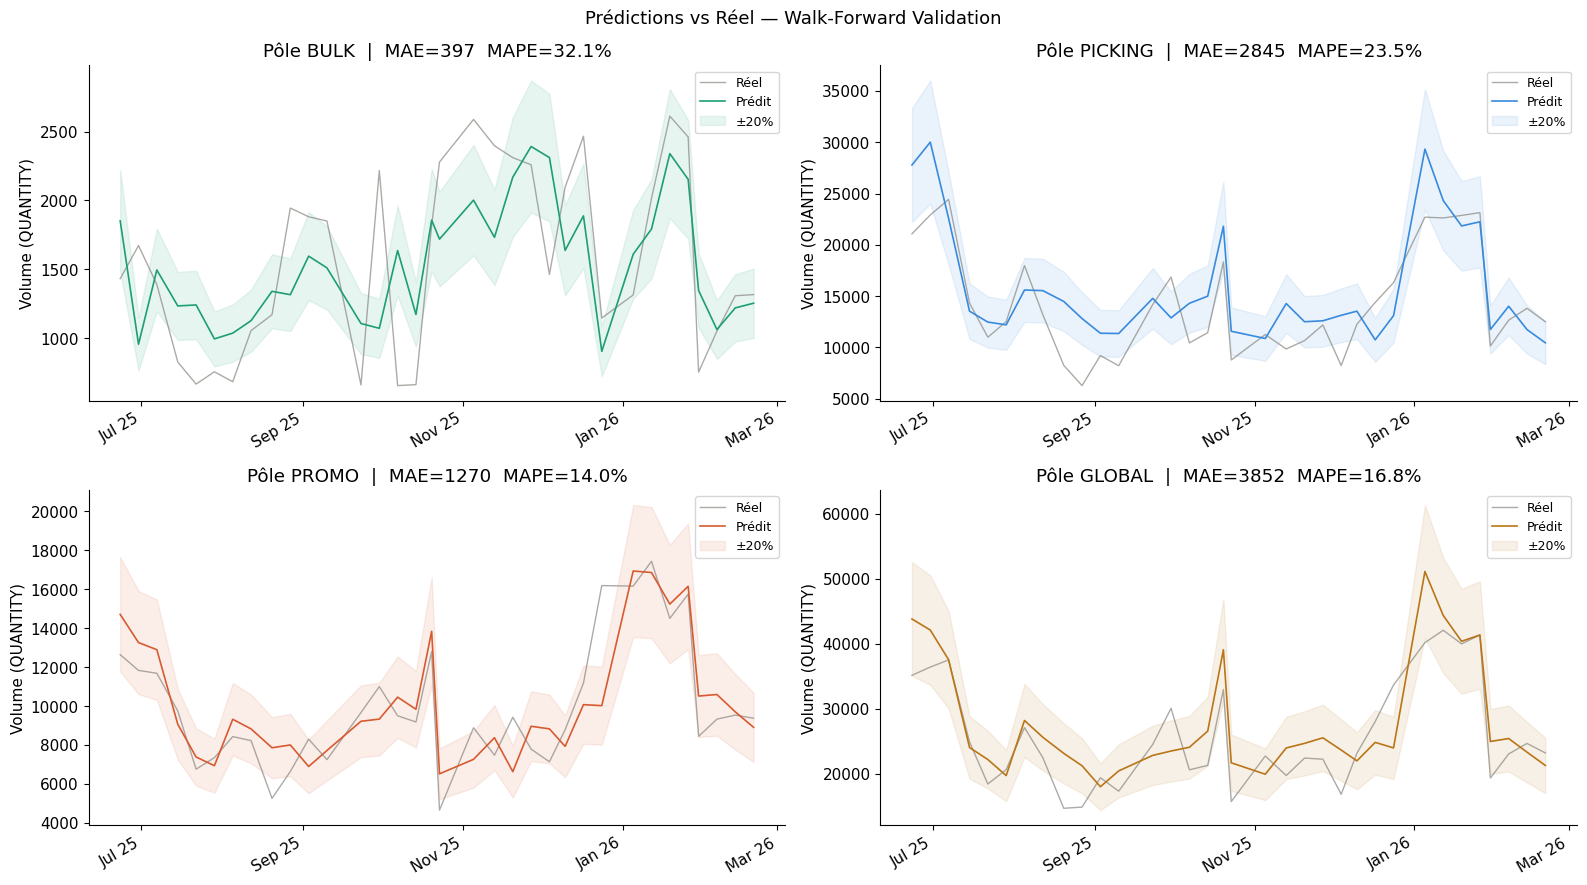

In [22]:
# ── Graphes Prédit vs Réel ───────────────────────────────────────────────────
colors = ['#1D9E75', '#378ADD', '#D85A30', '#BA7517']
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for ax, pole, color in zip(axes.flat, POLES, colors):
    res = results[pole]
    if res.empty:
        ax.set_title(f'{pole} — pas de données')
        continue

    ax.plot(res['date'], res['actual'], label='Réel',  color='#888780', linewidth=1.0, alpha=0.7)
    ax.plot(res['date'], res['pred'],   label='Prédit', color=color,    linewidth=1.2)
    ax.fill_between(res['date'],
                    res['pred'] * 0.8, res['pred'] * 1.2,
                    alpha=0.10, color=color, label='±20%')

    m = evaluate(res)
    ax.set_title(f"Pôle {pole}  |  MAE={m['MAE']:.0f}  MAPE={m['MAPE (%)']:.1f}%", fontweight='500')
    ax.set_ylabel('Volume (QUANTITY)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=9)

fig.suptitle('Prédictions vs Réel — Walk-Forward Validation', fontsize=13, fontweight='500')
plt.tight_layout()
plt.show()

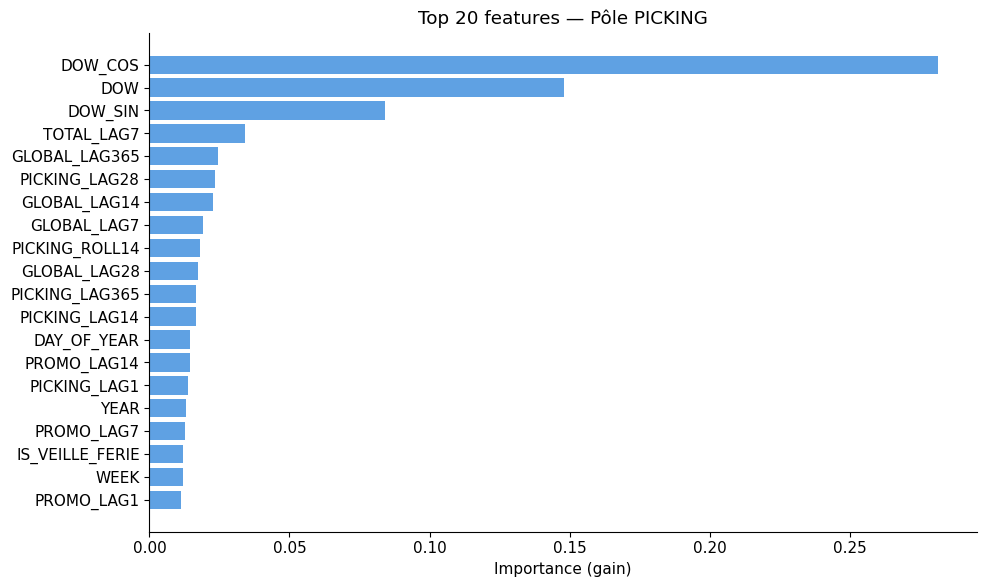

In [23]:
# ── Importance des features (pôle PICKING comme exemple) ────────────────────
pole_to_plot = 'PICKING'
model = models[pole_to_plot]

imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top20 = imp.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color='#378ADD', alpha=0.8)
ax.set_xlabel('Importance (gain)')
ax.set_title(f'Top 20 features — Pôle {pole_to_plot}', fontweight='500')
plt.tight_layout()
plt.show()

## 7. Conversion Volume → Nombre d'opérateurs

On apprend la **productivité historique** de chaque pôle : combien d'unités traite un opérateur par jour.
Si vous avez des données réelles sur les effectifs, remplacez la colonne `EFF_REEL_{pole}` dans vos fichiers.

In [24]:
# ── Option A : Productivité calculée depuis les données ──────────────────────
# Si vous avez les effectifs réels, chargez-les ici :
# effectifs_reels = pd.read_excel('effectifs.xlsx')  # colonnes : DATE, BULK_EFF, PICKING_EFF, ...
# et calculez PRODUCTIVITE[pole] = daily[pole] / effectifs_reels[f'{pole}_EFF']

# ── Hypothèse par défaut (à calibrer sur vos données réelles) ────────────────
# Productivité = nb de QUANTITY traitées par opérateur par jour
# Valeurs illustratives — REMPLACEZ ces chiffres par vos métriques réelles !
PRODUCTIVITE = {
    'BULK'   : 800,   # 800 unités / opérateur / jour
    'PICKING': 150,   # 150 unités / opérateur / jour
    'PROMO'  : 200,
    'GLOBAL' : 500,
}

def volume_to_operators(volumes: dict, productivite: dict, min_ops: int = 1) -> dict:
    """Convertit un dict {pole: volume_predit} en {pole: nb_operateurs}."""
    return {
        pole: max(min_ops, int(np.ceil(vol / productivite[pole])))
        for pole, vol in volumes.items()
    }

print("Productivité configurée (unités / opérateur / jour) :")
for p, v in PRODUCTIVITE.items():
    print(f"  {p:10s} : {v:,}")

Productivité configurée (unités / opérateur / jour) :
  BULK       : 800
  PICKING    : 150
  PROMO      : 200
  GLOBAL     : 500


## 8. Simulation — Prédiction J+1 en conditions réelles

Cette cellule simule exactement ce que le système ferait chaque soir pour prédire les besoins du lendemain.

In [26]:
def predict_next_day(date_today: str,
                     features_df: pd.DataFrame,
                     models: dict,
                     poles: list,
                     feature_cols: list,
                     productivite: dict) -> pd.DataFrame:
    """
    Prédit les volumes et le nombre d'opérateurs pour le lendemain de `date_today`.

    Parameters
    ----------
    date_today : str  — date du jour au format 'YYYY-MM-DD'
    """
    today = pd.Timestamp(date_today)
    row = features_df[features_df['DATE'] == today]

    if row.empty:
        raise ValueError(f"La date {date_today} n'est pas dans les données. "
                         f"Disponible : {features_df['DATE'].min().date()} → {features_df['DATE'].max().date()}")

    X = row[feature_cols]
    volumes_pred = {}
    for pole in poles:
        pred = float(np.maximum(0, models[pole].predict(X)[0]))
        volumes_pred[pole] = round(pred)

    operateurs = volume_to_operators(volumes_pred, productivite)

    return pd.DataFrame({
        'Pôle'             : poles,
        'Volume prédit'    : [volumes_pred[p] for p in poles],
        'Nb opérateurs'    : [operateurs[p]   for p in poles],
        'Productivité'     : [productivite[p]  for p in poles],
    })


# ─── EXEMPLE D'UTILISATION ───────────────────────────────────────────────────
DATE_SIMULATION = '2024-06-17'   # ← Changez cette date pour tester

try:
    prediction = predict_next_day(
        DATE_SIMULATION, features_df, models, POLES, FEATURE_COLS, PRODUCTIVITE
    )
    date_pred = pd.Timestamp(DATE_SIMULATION) + pd.Timedelta(days=1)

    print(f"\n{'='*52}")
    print(f"  Prévision pour le {date_pred.strftime('%A %d %B %Y').upper()}")
    print(f"  (basée sur les données connues au {DATE_SIMULATION})")
    print(f"{'='*52}")
    display(prediction)
    total_ops = prediction['Nb opérateurs'].sum()
    print(f"\n  TOTAL OPÉRATEURS NÉCESSAIRES : {total_ops}")
    print(f"{'='*52}")

except ValueError as e:
    print(f"⚠ {e}")


  Prévision pour le TUESDAY 18 JUNE 2024
  (basée sur les données connues au 2024-06-17)


,Pôle,Volume prédit,Nb opérateurs,Productivité
0,BULK,1356,2,800
1,PICKING,28586,191,150
2,PROMO,12013,61,200
3,GLOBAL,42020,85,500



  TOTAL OPÉRATEURS NÉCESSAIRES : 339


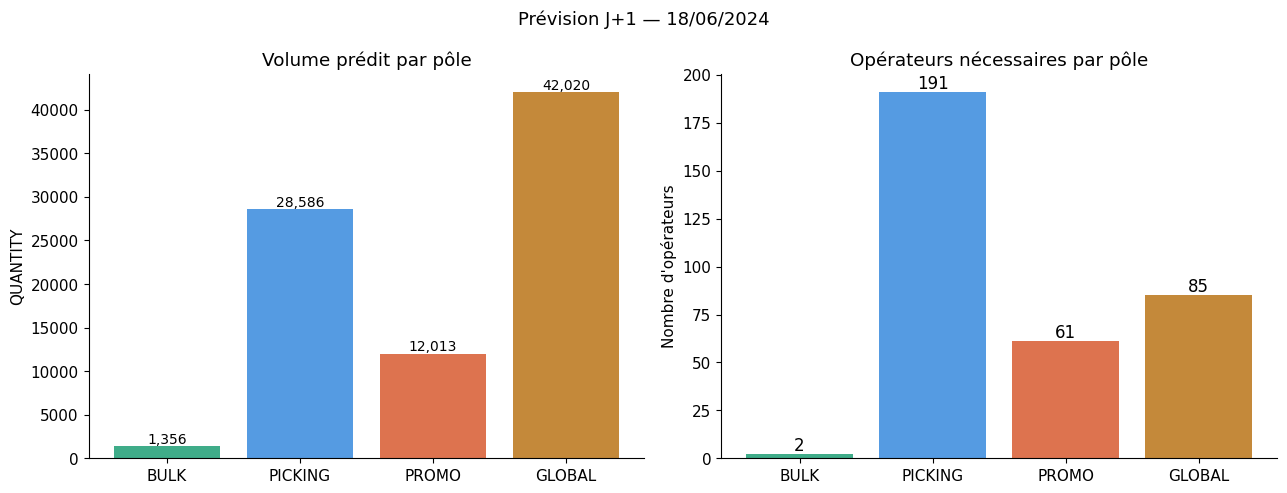

In [27]:
# ── Visualisation de la prédiction J+1 ──────────────────────────────────────
if 'prediction' in dir() and not prediction.empty:
    colors_poles = ['#1D9E75', '#378ADD', '#D85A30', '#BA7517']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Volumes prédits
    bars1 = ax1.bar(prediction['Pôle'], prediction['Volume prédit'],
                    color=colors_poles, alpha=0.85, edgecolor='none')
    ax1.set_title('Volume prédit par pôle', fontweight='500')
    ax1.set_ylabel('QUANTITY')
    for bar, val in zip(bars1, prediction['Volume prédit']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

    # Opérateurs
    bars2 = ax2.bar(prediction['Pôle'], prediction['Nb opérateurs'],
                    color=colors_poles, alpha=0.85, edgecolor='none')
    ax2.set_title('Opérateurs nécessaires par pôle', fontweight='500')
    ax2.set_ylabel('Nombre d\'opérateurs')
    for bar, val in zip(bars2, prediction['Nb opérateurs']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(val), ha='center', va='bottom', fontsize=12, fontweight='500')

    fig.suptitle(f"Prévision J+1 — {date_pred.strftime('%d/%m/%Y')}", fontsize=13, fontweight='500')
    plt.tight_layout()
    plt.show()

## 9. (Optionnel) Simulation complète de la période de test

Rejoue l'ensemble de la walk-forward sur toutes les dates disponibles et calcule les opérateurs prédits vs réels.

In [28]:
def replay_walk_forward(features_df: pd.DataFrame,
                        results: dict,
                        poles: list,
                        productivite: dict) -> pd.DataFrame:
    """
    Reconstruit un tableau avec, pour chaque jour de test :
    - Volume réel / prédit par pôle
    - Opérateurs réels / prédits par pôle
    """
    rows = []
    for pole in poles:
        res = results[pole]
        for _, r in res.iterrows():
            rows.append({
                'date'        : r['date'],
                'pole'        : pole,
                'vol_reel'    : r['actual'],
                'vol_pred'    : r['pred'],
                'ops_reel'    : max(1, int(np.ceil(r['actual'] / productivite[pole]))),
                'ops_pred'    : max(1, int(np.ceil(r['pred']   / productivite[pole]))),
            })

    df_replay = pd.DataFrame(rows)
    df_replay['date'] = pd.to_datetime(df_replay['date'])
    return df_replay.sort_values(['date','pole'])

replay = replay_walk_forward(features_df, results, POLES, PRODUCTIVITE)
print(f"Jours simulés : {replay['date'].nunique()}")
display(replay.head(12))

Jours simulés : 34


,date,pole,vol_reel,vol_pred,ops_reel,ops_pred
0,2025-06-23,BULK,1433.0,1852.2,2,3
102,2025-06-23,GLOBAL,35144.0,43816.4,71,88
34,2025-06-23,PICKING,21070.0,27779.1,141,186
68,2025-06-23,PROMO,12641.0,14709.7,64,74
1,2025-06-30,BULK,1673.0,957.3,3,2
103,2025-06-30,GLOBAL,36413.0,42111.1,73,85
35,2025-06-30,PICKING,22908.0,30010.8,153,201
69,2025-06-30,PROMO,11832.0,13261.0,60,67
2,2025-07-07,BULK,1391.0,1495.8,2,2
104,2025-07-07,GLOBAL,37509.0,37552.1,76,76


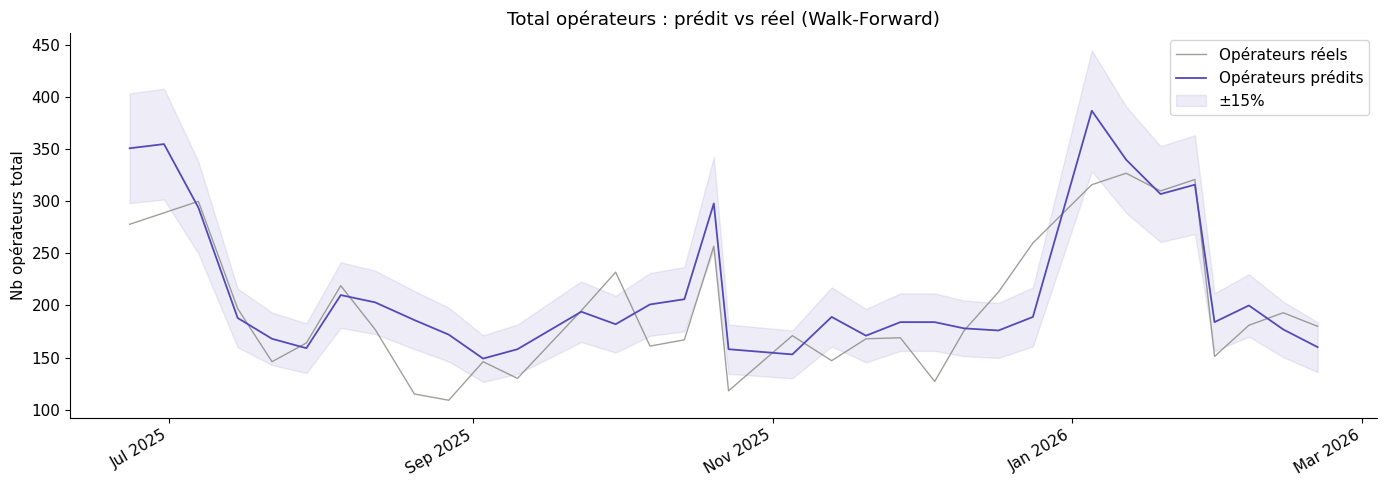

Écart moyen absolu sur le total opérateurs : 29.9 opérateur(s)/jour


In [29]:
# ── Total opérateurs par jour : prédit vs réel ───────────────────────────────
daily_ops = replay.groupby('date')[['ops_reel','ops_pred']].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_ops.index, daily_ops['ops_reel'], color='#888780', linewidth=1.0,
        label='Opérateurs réels', alpha=0.8)
ax.plot(daily_ops.index, daily_ops['ops_pred'], color='#534AB7', linewidth=1.3,
        label='Opérateurs prédits')
ax.fill_between(daily_ops.index,
                daily_ops['ops_pred'] * 0.85,
                daily_ops['ops_pred'] * 1.15,
                alpha=0.10, color='#534AB7', label='±15%')
ax.set_ylabel('Nb opérateurs total')
ax.set_title('Total opérateurs : prédit vs réel (Walk-Forward)', fontweight='500')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

# Écart moyen
ecart = (daily_ops['ops_pred'] - daily_ops['ops_reel']).abs().mean()
print(f"Écart moyen absolu sur le total opérateurs : {ecart:.1f} opérateur(s)/jour")

## 10. Export des résultats

In [30]:
OUTPUT_FILE = 'resultats_previsions.xlsx'

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    # Métriques
    metrics_df.to_excel(writer, sheet_name='Métriques')

    # Prédictions OOS par pôle
    for pole in POLES:
        results[pole].to_excel(writer, sheet_name=f'OOS_{pole}', index=False)

    # Replay complet
    replay.to_excel(writer, sheet_name='Replay_opérateurs', index=False)

    # Total journalier
    daily_ops.to_excel(writer, sheet_name='Total_jour')

print(f"Fichier exporté : {OUTPUT_FILE}")

Fichier exporté : resultats_previsions.xlsx


---
## Notes et prochaines étapes

### Calibration de la productivité
La conversion volume → opérateurs repose sur `PRODUCTIVITE`. Pour calibrer ces valeurs :
1. Chargez vos données d'effectifs réels (pointages, planning)
2. Calculez `productivite_pole = daily[pole] / effectif_reel_pole`
3. Utilisez la médiane ou le percentile 75 pour être conservateur

### Améliorations possibles
- **Tuning des hyperparamètres** : `GridSearchCV` ou `Optuna` sur les paramètres XGBoost
- **Modèle par saison** : S et W ont des dynamiques différentes
- **Ajout de features** : commandes déjà connues pour J+1, météo, absentéisme historique
- **Prediction intervals** : utiliser XGBoost avec `quantile regression` pour des intervalles de confiance
- **Comparaison de modèles** : Prophet, LightGBM, Random Forest en parallèle